In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import auxiliary_functions
import ruptures as rpt

In [2]:
selected_lamdas = np.logspace(-5,0,10)
window = 1

In [3]:
with open('block2activities.pkl', 'rb') as handle:
    tnet = pickle.load(handle)[0]
net = tnet['tnet']

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [4]:
Conditional_S_selected1 = []
for i, lamda in enumerate(selected_lamdas):
    with open(f'/scratch/tmp/180/skoove/block2activities/net{0}/window_S/{window}/window_S{lamda:.11f}', 'rb') as f:
        S_rate = pickle.load(f)
        Conditional_S_selected1.append(S_rate['signal'][f'{lamda:.11f}'])

In [56]:
len(Conditional_S_selected1[1])

46210

In [6]:
# detection
algo = rpt.Pelt(model="rbf").fit(np.array(Conditional_S_selected1[5]))

In [7]:
algo.n_samples

46210

In [8]:
result = algo.predict(pen=10)

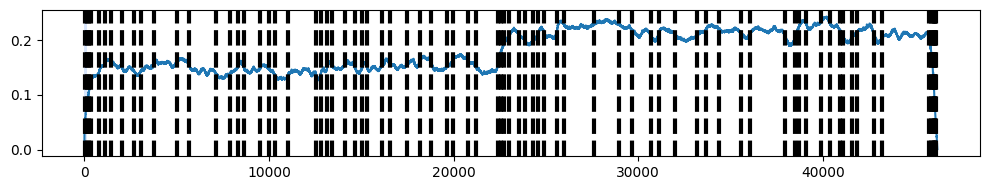

In [10]:
# display
rpt.display(np.array(Conditional_S_selected1[5]), [tnet['t_split']], result)
plt.show()

In [17]:
# detection
algo_window = rpt.Window(model="rbf").fit(signal = np.array(Conditional_S_selected1[5]))

In [105]:
result_window = algo_window.predict(n_bkps=5)

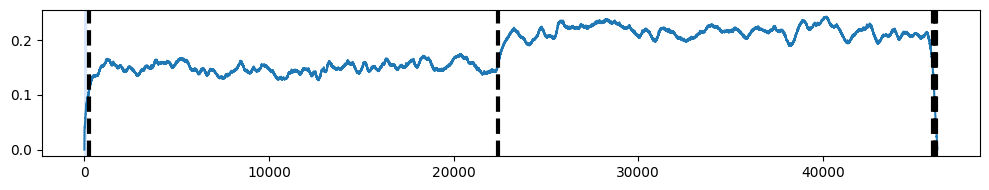

In [106]:
# display
rpt.display(np.array(Conditional_S_selected1[5]), [tnet['t_split']], result_window)
plt.show()

In [ ]:
pred_indeces = [i-1 for i in result_window]

In [ ]:
print(net.times[pred_indeces])
print(tnet['t_split'])

Index([2.0084637139205124, 116.77262503358882, 200.27102440710814,
        201.3743527590576, 203.12815449631512, 210.47250086772468],
      dtype='float64', name='times')
117


In [57]:
inter_tau_1 = 2
density_1 = 100
head = inter_tau_1 / 2 * np.log(density_1 * inter_tau_1)

In [81]:
# Find the first index where value > 5 (exclusive of 5)
# Using 'right' side ensures we move past any exact matches of 5
start_idx = np.searchsorted(net.times, head, side='right')

# Find the first index where value >= 200 (exclusive of 200)
# Using 'left' side finds the first occurrence of 200 or the next largest value
end_idx = np.searchsorted(net.times, 199, side='left')

# Get the range of indices
stationary_indices = np.arange(start_idx, end_idx)

# To see the actual values:
selected_values = net.times[start_idx:end_idx]

In [70]:
stationary_indices

array([  840,   841,   842, ..., 45927, 45928, 45929], shape=(45090,))

In [71]:
len(net.times)

46210

In [77]:
selected_values

Index([ 5.300950190470207,  5.312302340765652,  5.314437236739669,
        5.318327337093497,  5.341223247168225,  5.349032594770537,
        5.353869192586741,  5.370415230169099,  5.386855942386536,
        5.387046433541477,
       ...
        199.9675622000167, 199.96990590921754, 199.97760736369457,
       199.98127188268094, 199.98216124489952,  199.9845786469631,
       199.98810395984478, 199.99023386652885,  199.9914455697619,
       199.99689521383846],
      dtype='float64', name='times', length=45090)

In [80]:
np.array(Conditional_S_selected1[5])[stationary_indices][-90:-80]

array([0.18752873, 0.18625379, 0.18582359, 0.18485398, 0.18438987,
       0.18595168, 0.18547737, 0.18539502, 0.18509833, 0.18498524])

In [82]:
# detection
algo_window_2 = rpt.Window(model="rbf").fit(signal = np.array(Conditional_S_selected1[5])[stationary_indices])

In [97]:
result_window_2 = algo_window_2.predict(n_bkps=1)

In [98]:
idx = (np.abs(selected_values - tnet['t_split'])).argmin()
closest_val = selected_values[idx]

In [99]:
closest_val

np.float64(116.99986267713024)

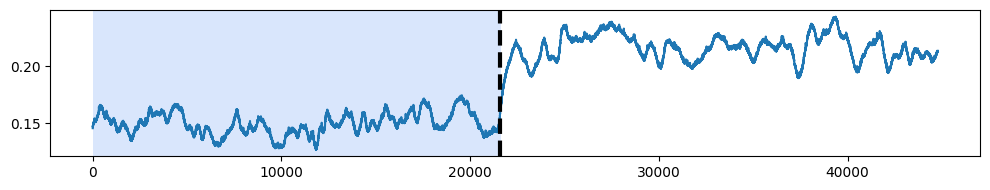

In [100]:
# display
rpt.display(np.array(Conditional_S_selected1[5])[stationary_indices], [idx], result_window_2)
plt.show()

## Synthetic Example

In [ ]:
# generate signal
n_samples, dim, sigma = 1000, 3, 4
n_bkps = 2  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

In [ ]:
signal

In [ ]:
bkps

In [ ]:
# detection
algo2 = rpt.Pelt(model="rbf").fit(signal)
result2 = algo2.predict(pen=10)

# display
rpt.display(signal, bkps, result2)
plt.show()

In [ ]:
result2

In [ ]:
signal.values()